# Zadanie obowiązkowe [0-10] pkt

1. [0-1.5 pkt] Porównaj wyniki k-means z k-medoids, testując przynajmniej trzy różne metryki (użyj [tego API](https://scikit-learn-extra.readthedocs.io/en/stable/generated/sklearn_extra.cluster.KMedoids.html)). Wyrysuj klastry i omów wyniki.
1. [0-2 pkt] Użyj DSBSCAN i wyrysuj klastry dla różnych kombinacji wartości `eps`, `min_samples` i `metric`. Porównaj wyniki z metodami wyżej.
2. [0-2 pkt] Użyj HDBSCAN, testując różne kombinacje parametrów. Czy wyniki różnią się od DBSCAN?
3. [0-2.5 pkt] Uzyj [klastrowania aglomeracyjnego](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html). Dla każdej wartości parametru `linkage`, wyrysuj [dendrogram](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html). Na podstawie dendrogramów, dobierz, w Twojej ocenie, optymalne parametry `n_clusters` albo `distance_threshold` (chodzi o określenie, czy w dendrogramie, na pewnym poziomie odcięcia, widać ewidentne klastry). Wyrysuj klastry i skomentuj wyniki.  
1. [0-1 pkt] Sprawdź wyniki poszczególnych metod klastrowania bez skalowania cech. Zinterpretuj wyniki.
1. [0-1 pkt] Który z algorytmów działa najlepiej dla tego problemu? Skomentuj wyniki.

# 0. Importy niezbędnych bibliotek i danych.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
main_path = Path(".")
coord_dir = main_path / "coords"

In [4]:
for file_path in sorted(coord_dir.glob("*.csv")):
    df = pd.read_csv(file_path)
    coords = df[['x', 'y', 'z']].values
    dist_mat = squareform(pdist(coords, metric='euclidean'))
    print(file_path.stem)
    break

16pkA01


In [5]:
metadata = pd.read_csv(Path('metadata.txt'), delimiter='\t', 
                       header=None, names=['protein', 'C', 'A', 'T', 'H'], index_col='protein')

In [6]:
from sklearn.decomposition import PCA

features_npz = np.load("features.npz")
feature_vectors = {key: features_npz[key] for key in features_npz.files}

columns = [
    "num_nodes", "num_edges", "mean_degree", "var_degree",
    "mean_weighted_degree", "density", "avg_neighbor_degree"
]
data = pd.DataFrame.from_dict(feature_vectors, orient="index", columns=columns)

X = data[['density', 'mean_weighted_degree']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Porównaj wyniki k-means z k-medoids, testując przynajmniej trzy różne metryki. Wyrysuj klastry i omów wyniki.

  File "c:\Users\Jakub\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Jakub\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Jakub\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Jakub\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
            

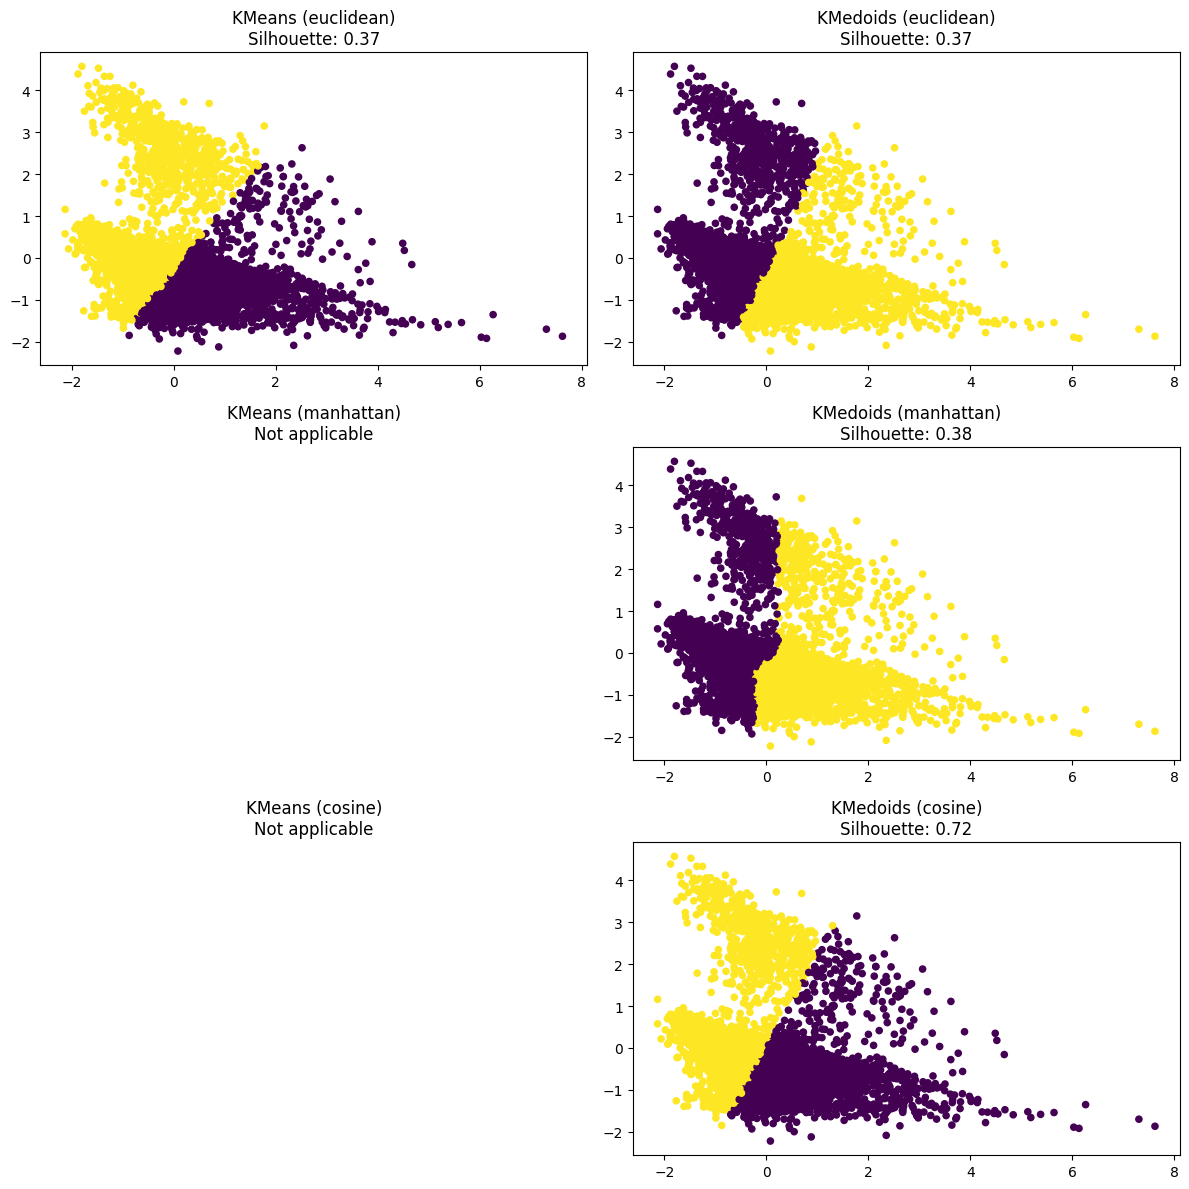

     Method     Metric  Silhouette
0    KMeans  euclidean    0.373538
1  KMedoids  euclidean    0.373115
2  KMedoids  manhattan    0.383423
3  KMedoids     cosine    0.715154


In [7]:
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

metrics = ['euclidean', 'manhattan', 'cosine']
results = []

fig, axes = plt.subplots(len(metrics), 2, figsize=(12, 4 * len(metrics)))

for i, metric in enumerate(metrics):
    # KMeans
    if metric == 'euclidean':
        kmeans = KMeans(n_clusters=2, random_state=42)
        kmeans_labels = kmeans.fit_predict(X_scaled)
        silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels, metric=metric)
        results.append({'Method': 'KMeans', 'Metric': metric, 'Silhouette': silhouette_kmeans})
        axes[i, 0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', s=20)
        axes[i, 0].set_title(f'KMeans ({metric})\nSilhouette: {silhouette_kmeans:.2f}')
    else:
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f'KMeans ({metric})\nNot applicable')

    # KMedoids
    kmedoids = KMedoids(n_clusters=2, metric=metric, random_state=42)
    kmedoids_labels = kmedoids.fit_predict(X_scaled)
    silhouette_kmedoids = silhouette_score(X_scaled, kmedoids_labels, metric=metric)
    results.append({'Method': 'KMedoids', 'Metric': metric, 'Silhouette': silhouette_kmedoids})
    axes[i, 1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmedoids_labels, cmap='viridis', s=20)
    axes[i, 1].set_title(f'KMedoids ({metric})\nSilhouette: {silhouette_kmedoids:.2f}')

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

[KOMENTARZ] Wszystkie eksperymenty dały dosyć podane wyniki, z wyjątkiem KMedoids z metryką cosine - wynik silhouette przekroczył 0.7 i jest to zdecydowanie najwyższy uzyskany wynik. Widać na tym przykładzie, że dobór odpowiedniej metryki może być bardzo istotny przy klasteryzacji.

# 2. Użyj DSBSCAN i wyrysuj klastry dla różnych kombinacji wartości `eps`, `min_samples` i `metric`. Porównaj wyniki z metodami wyżej.

In [8]:
from sklearn.cluster import DBSCAN

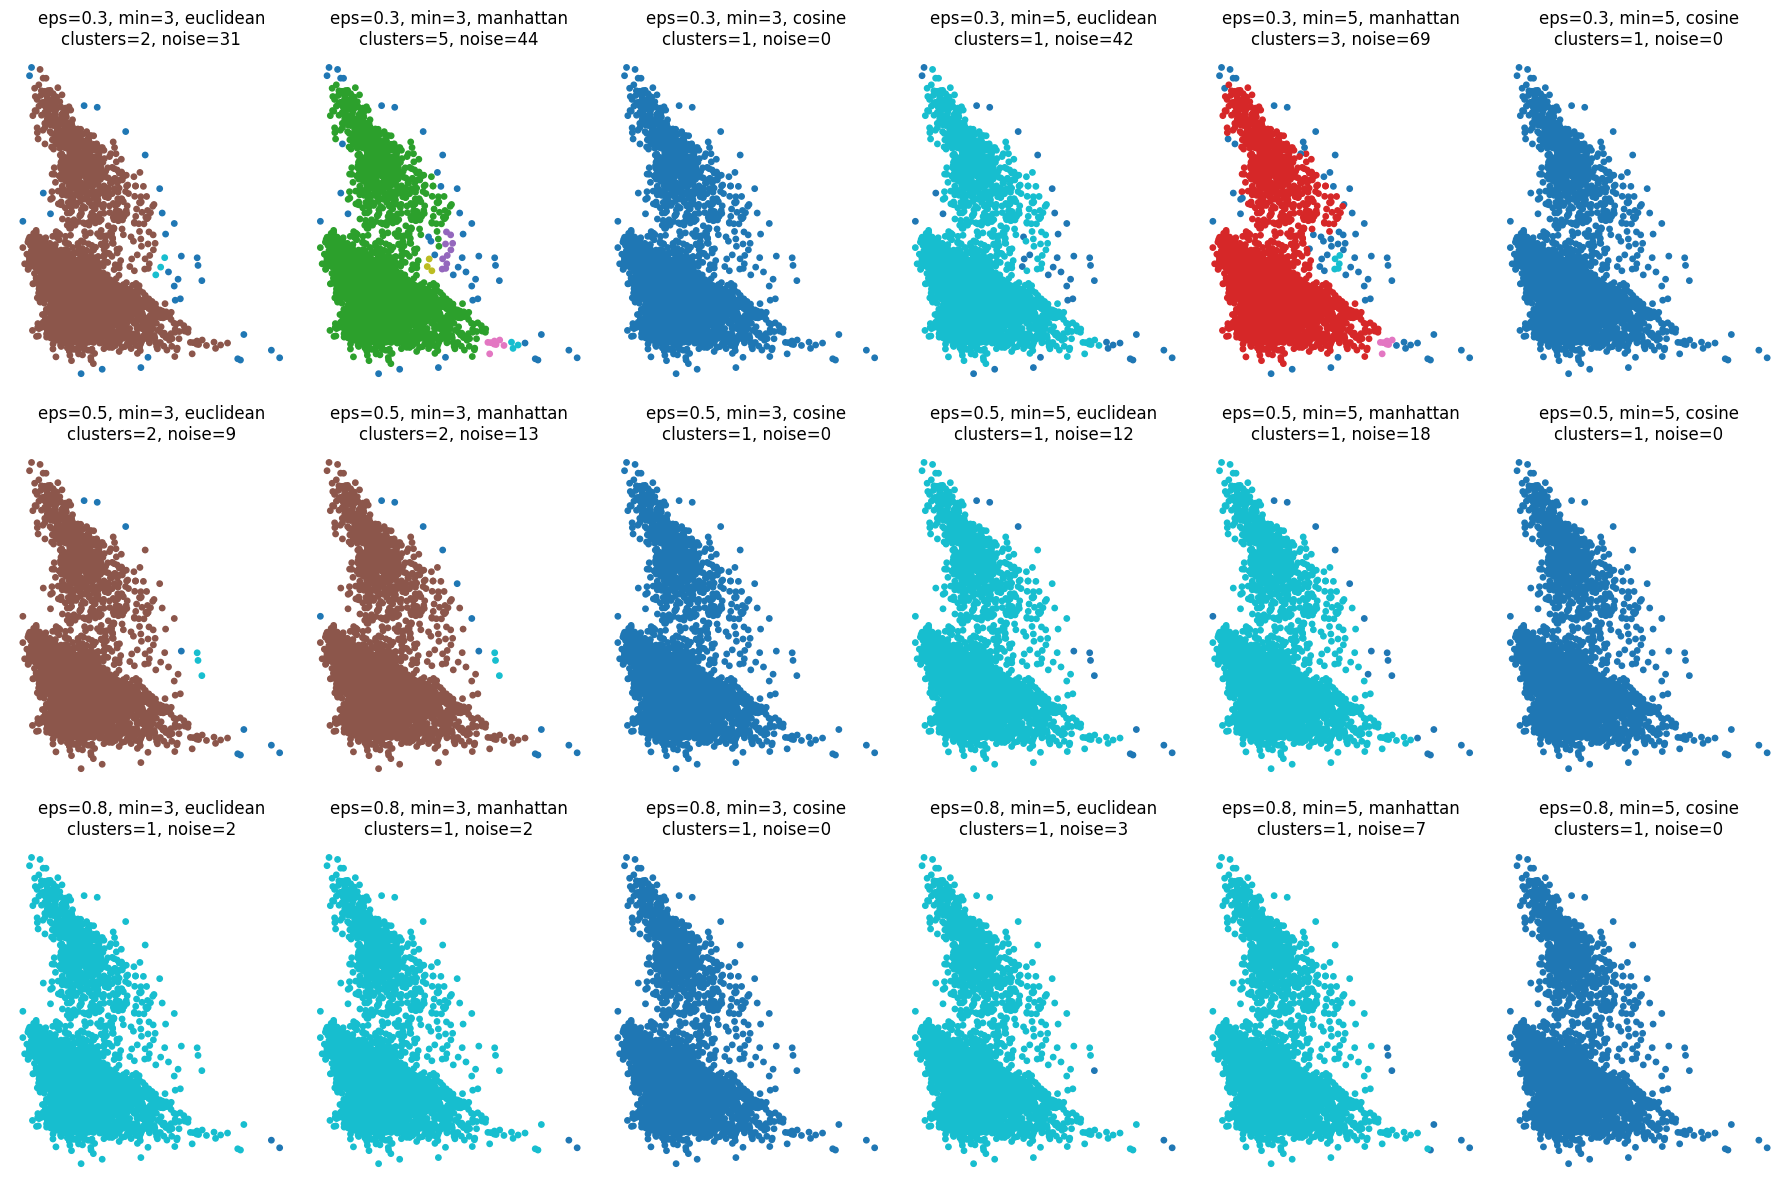

    eps  min_samples     metric  n_clusters  noise_points  silhouette
0   0.3            3  euclidean           2            31    0.468670
1   0.3            3  manhattan           5            44    0.254014
2   0.3            3     cosine           1             0         NaN
3   0.3            5  euclidean           1            42         NaN
4   0.3            5  manhattan           3            69    0.376947
5   0.3            5     cosine           1             0         NaN
6   0.5            3  euclidean           2             9    0.627214
7   0.5            3  manhattan           2            13    0.593967
8   0.5            3     cosine           1             0         NaN
9   0.5            5  euclidean           1            12         NaN
10  0.5            5  manhattan           1            18         NaN
11  0.5            5     cosine           1             0         NaN
12  0.8            3  euclidean           1             2         NaN
13  0.8            3

In [9]:
eps_values = [0.3, 0.5, 0.8]
min_samples_values = [3, 5]
metrics = ['euclidean', 'manhattan', 'cosine']
results = []

fig, axes = plt.subplots(len(eps_values), len(min_samples_values) * len(metrics), figsize=(18, 12))

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        for k, metric in enumerate(metrics):
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
            labels = dbscan.fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise = list(labels).count(-1)
            silhouette = silhouette_score(X_scaled, labels, metric=metric) if n_clusters > 1 else None

            results.append({
                'eps': eps, 'min_samples': min_samples, 'metric': metric,
                'n_clusters': n_clusters, 'noise_points': noise, 'silhouette': silhouette
            })

            ax = axes[i, j * len(metrics) + k]
            ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10', s=15)
            ax.set_title(f"eps={eps}, min={min_samples}, {metric}\nclusters={n_clusters}, noise={noise}")
            ax.axis('off')

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

[KOMENTARZ] Dla przyjętych parametrów zaskakująco często wyznaczany jest tylko jeden klaster (stąd NaN w kolumnie silhouette), ciężko wyznaczyć najbardziej odpowiednią metrykę. Przyjęty epsilon bardzo silnie wpływa na wynik, dla mniejszych wartości szum był istotnie większy. Mniej istotny wpływ miało min_samples.

# 3. Użyj HDBSCAN, testując różne kombinacje parametrów. Czy wyniki różnią się od DBSCAN?

In [10]:
import hdbscan

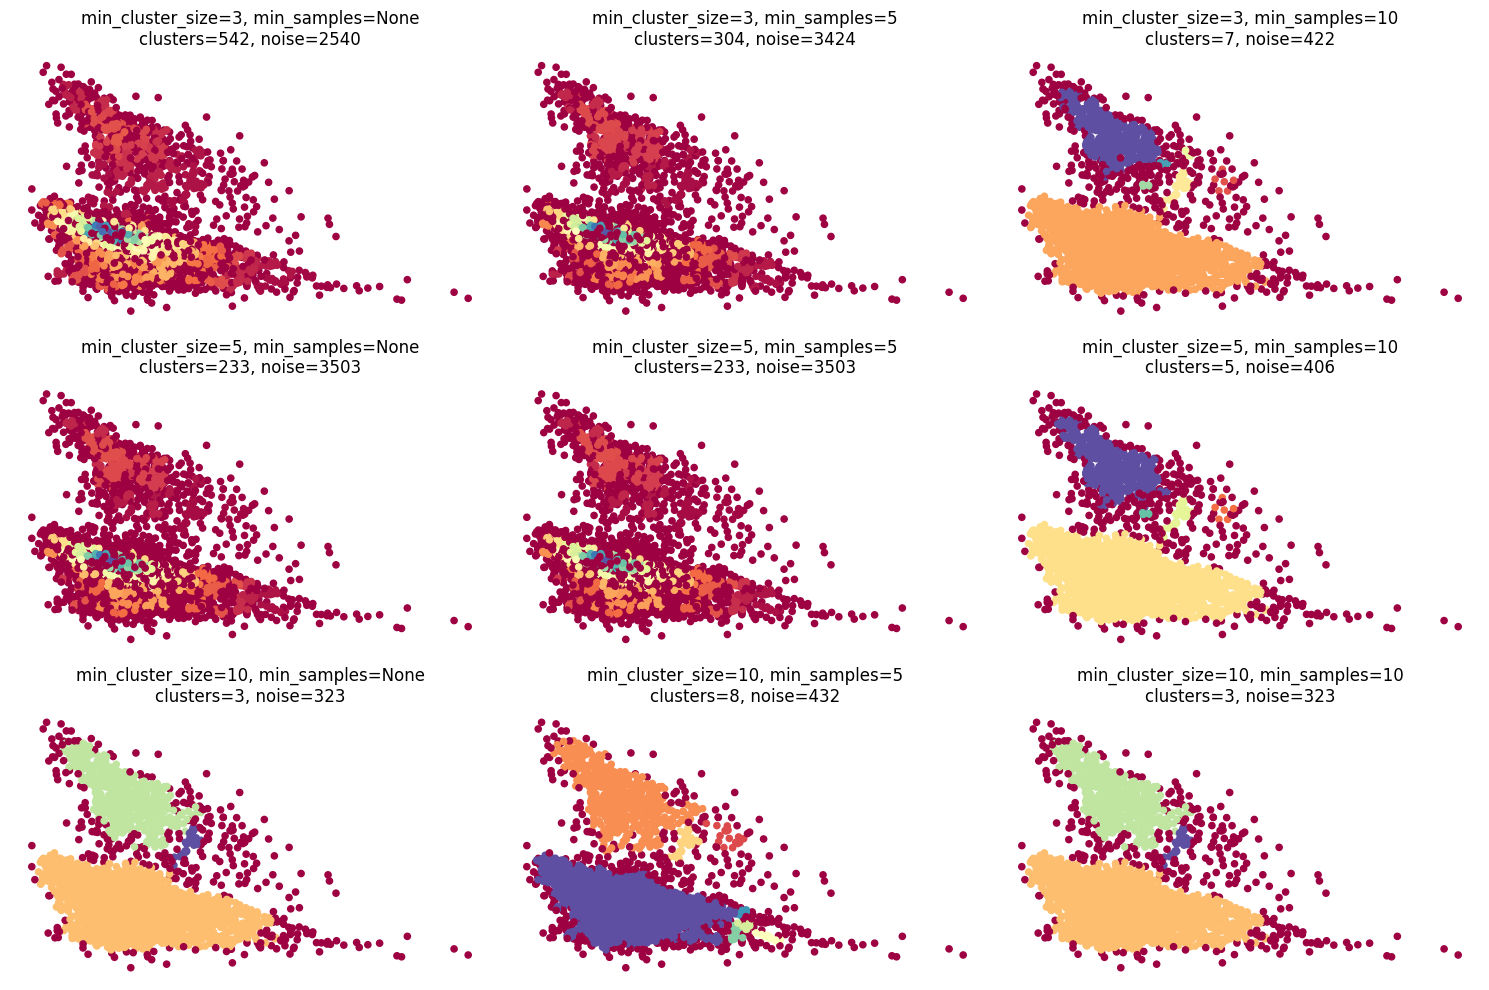

   min_cluster_size  min_samples  n_clusters  noise_points  silhouette
0                 3          NaN         542          2540   -0.082602
1                 3          5.0         304          3424   -0.276160
2                 3         10.0           7           422    0.292504
3                 5          NaN         233          3503   -0.283264
4                 5          5.0         233          3503   -0.283264
5                 5         10.0           5           406    0.301366
6                10          NaN           3           323    0.403309
7                10          5.0           8           432    0.362795
8                10         10.0           3           323    0.403309


In [11]:
min_cluster_sizes = [3, 5, 10]
min_samples_vals = [None, 5, 10]

results = []

fig, axes = plt.subplots(len(min_cluster_sizes), len(min_samples_vals), figsize=(15, 10))
for i, min_cluster_size in enumerate(min_cluster_sizes):
    for j, min_samples in enumerate(min_samples_vals):
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        labels = clusterer.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)
        silhouette = silhouette_score(X_scaled, labels) if n_clusters > 1 else None

        results.append({
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'noise_points': noise,
            'silhouette': silhouette
        })

        ax = axes[i, j]
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='Spectral', s=20)
        title = f"min_cluster_size={min_cluster_size}, min_samples={min_samples}\nclusters={n_clusters}, noise={noise}"
        ax.set_title(title)
        ax.axis('off')

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

[KOMENTARZ] Wyniki są kiepskie, ta metoda nie nadaje się do tego problemu. Bardzo ważnym parametrem jest min_cluster_size, jego większa wartość ograniczała tworzenie zbyt wielu niewielkich klastrów i zmniejszał wielkość szumu.

# 4. Użyj klastrowania aglomeracyjnego. Dla każdej wartości parametru `linkage`, wyrysuj `dendrogram`. Na podstawie dendrogramów, dobierz, w Twojej ocenie, optymalne parametry `n_clusters` albo `distance_threshold` (chodzi o określenie, czy w dendrogramie, na pewnym poziomie odcięcia, widać ewidentne klastry). Wyrysuj klastry i skomentuj wyniki.  

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

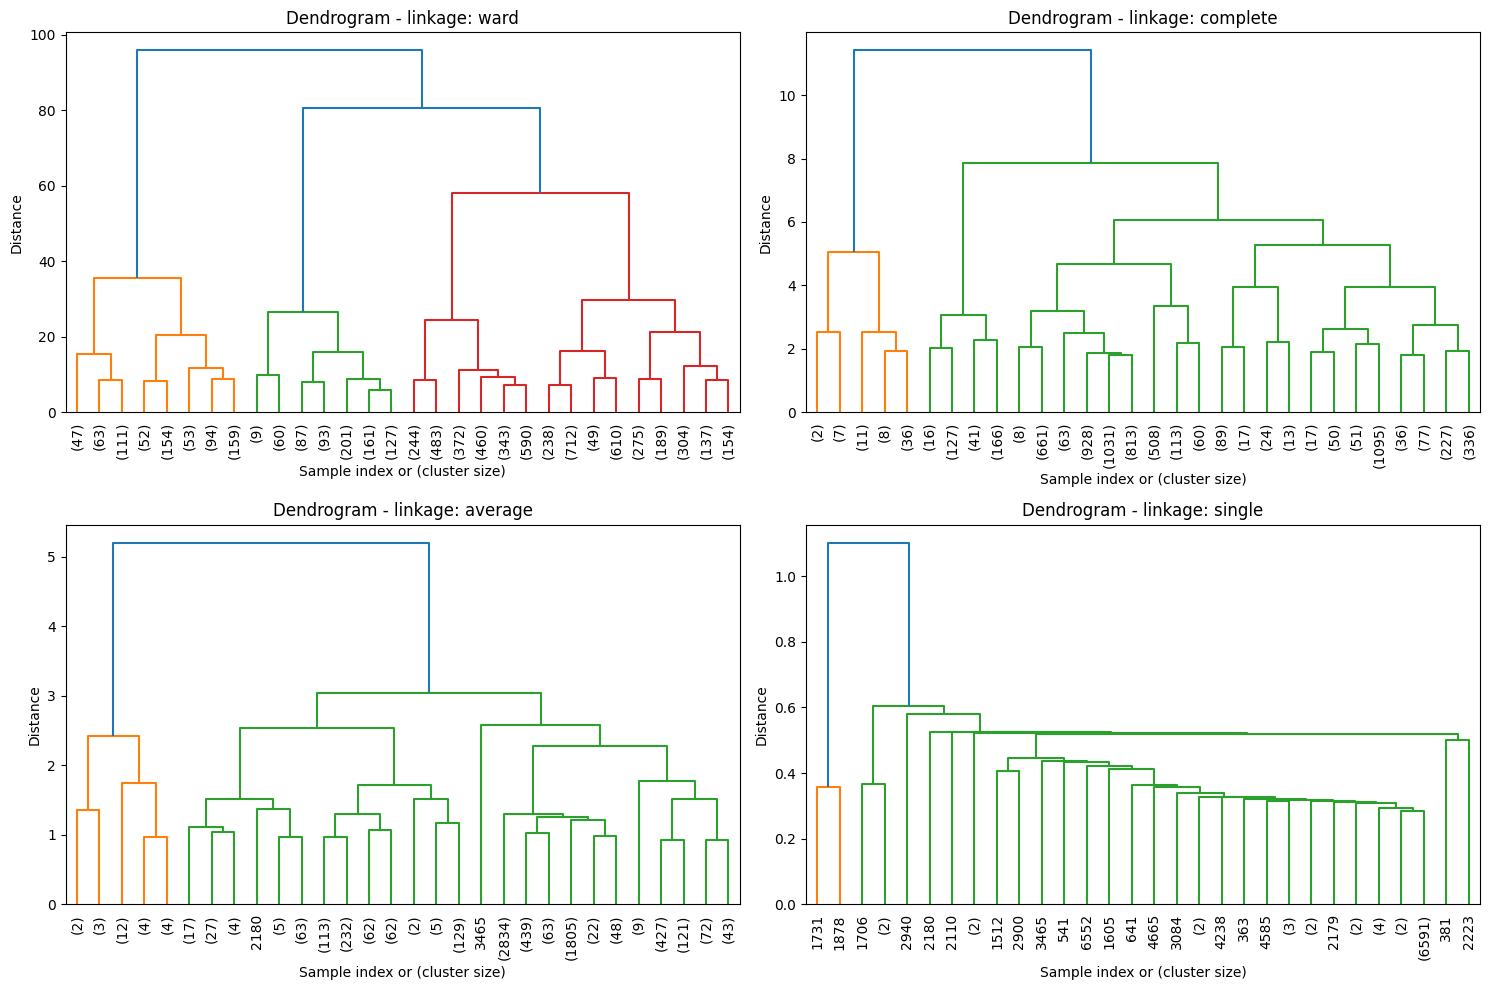

In [13]:
def plot_dendrogram(linkage_matrix, title, ax):
    dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
    ax.set_title(title)
    ax.set_xlabel("Sample index or (cluster size)")
    ax.set_ylabel("Distance")

linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, method in enumerate(linkage_methods):
    row, col = divmod(i, 2)
    Z = scipy_linkage(X_scaled, method=method)
    plot_dendrogram(Z, title=f"Dendrogram - linkage: {method}", ax=axes[row][col])

plt.tight_layout()
plt.show()

[KOMENTARZ] 
- WARD - 2 klastry
- COMPLETE - 3 klastry
- AVERAGE - 3 klastry
- SINGLE - trudno powiedzieć, wynik jest bardzo słaby

# 5. Sprawdź wyniki poszczególnych metod klastrowania bez skalowania cech. Zinterpretuj wyniki.

In [14]:
from sklearn.cluster import AgglomerativeClustering

In [15]:
X_unscaled = data[['density', 'mean_weighted_degree']].copy()

results_unscaled = []

# KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_unscaled)
score_kmeans = silhouette_score(X_unscaled, labels_kmeans)
results_unscaled.append(('KMeans', 2, score_kmeans))

# KMedoids
kmedoids = KMedoids(n_clusters=2, metric='euclidean', random_state=42)
labels_kmedoids = kmedoids.fit_predict(X_unscaled)
score_kmedoids = silhouette_score(X_unscaled, labels_kmedoids)
results_unscaled.append(('KMedoids', 2, score_kmedoids))

# DBSCAN
dbscan = DBSCAN(eps=0.25, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_unscaled)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
score_dbscan = silhouette_score(X_unscaled, labels_dbscan) if n_clusters_dbscan > 1 else None
results_unscaled.append(('DBSCAN', n_clusters_dbscan, score_dbscan))

# HDBSCAN
hdbscan = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5)
labels_hdbscan = hdbscan.fit_predict(X_unscaled)
n_clusters_hdbscan = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
score_hdbscan = silhouette_score(X_unscaled, labels_hdbscan) if n_clusters_hdbscan > 1 else None
results_unscaled.append(('HDBSCAN', n_clusters_hdbscan, score_hdbscan))

# Agglomerative
agg = AgglomerativeClustering(n_clusters=2)
labels_agg = agg.fit_predict(X_unscaled)
score_agg = silhouette_score(X_unscaled, labels_agg)
results_unscaled.append(('Agglomerative', 2, score_agg))

results_df = pd.DataFrame(results_unscaled, columns=['Method', 'Clusters', 'Silhouette'])
print(results_df)


          Method  Clusters  Silhouette
0         KMeans         2    0.776543
1       KMedoids         2    0.392305
2         DBSCAN        59    0.174425
3        HDBSCAN       285    0.099856
4  Agglomerative         2    0.776023


[KOMENTARZ] Wyniki dla nieskalowanych metod są bardzo różne dla każdej z metod. KMeans i klastrowanie aglomeracyjne ma bardzo wysokie wyniki. Dla DBSCAN i HDBSCAN trudno znaleźć poprawny epsilon stąd tak słaby wynik i liczba klastrów - tutaj zdecydowanie lepiej korzystać ze skalowanych cech.

# 6. Który z algorytmów działa najlepiej dla tego problemu? Skomentuj wyniki.

[KOMENTARZ] W naszym przypadku prawdopodobnie najlepsza jest KMedoids, dawała ona dobre wyniki, była odporna na wartości odstające. DBSACAN i HDBSACN są trudne do dostrojenia, a klastrowanie aglomeracyjne jest mniej przewidywalne.

# Zadanie dodatkowe [0-10] pkt

1. [0-7 pkt] Wytrenuj sieć konwolucyjną (CNN) na macierzach podobieństwa, przewidując klasy CATH (problem klasyfikacji). Pamiętaj o ewaluacji na zbiorze walidacyjnym.
2. [0-1 pkt] Uruchom wytrenowany model na wszystkich białkach. Użyj wag z ostatniej warstwy jako wektora cech.
3. [0-1 pkt] Dokonaj redukcji wymiarowości wektora cech do dwóch wymiarów np. za pomocą PCA.
4. [0-1 pkt] Czy tak skonstruowane cechy korelują z klasą białek?